# Training the Deployed Opposition Prediction Models

Fits the model variants actually deployed by `predict_location.py` -- one FULL/NO_ZONING/COUNTY_ONLY set per model, each fit and calibrated under a strict 40% train / 20% calibrate / 40% test split. Run against the real facility+county feature dataset (1,294 facilities, county predictors joined on FIPS for 1,100 of them).

**Two adaptations for this run, both noted inline in the code:** (1) `HERE = Path(__file__).parent` doesn't work inside a notebook cell, so it's anchored to the notebook's working directory instead -- same effect, notebook-only fix. (2) M3 needs a county feature (`events_per_10k_pop_log`) built by a later rebuild stage (`build_county_features.py`) this environment doesn't have inputs for, so M3 is skipped rather than fabricated -- M1, M2, and M4 (the primary deployable model) don't depend on it and fit normally.

**2026-08-25 update:** this run also carries a fix for a real bug found in M2's calibration step -- see "Bug found" below, after the main fit. The headline numbers in this notebook (and in the project README) are the corrected ones.

### Docstring, imports, constants

In [1]:
"""
build_scenario_models.py — fallback model variants for incomplete user input.

The champion specs assume four SITE-level inputs the user may not have:
    by_right, industrial_zoned, build_converted, project_year

Scoring with those median-imputed biases the result DOWNWARD — all three zoning variables
have negative coefficients and protective training medians, so a missing value is treated
as the protective case. Rather than silently imputing, this builds variants FIT WITHOUT the
unavailable predictors, so the deployed model matches the information actually supplied.

VARIANTS (per model)
    FULL          all champion predictors — user supplied everything
    NO_ZONING     drops by_right / industrial_zoned / build_converted, keeps project_year
    COUNTY_ONLY   drops all four site inputs — pure county-level screen

Each variant is fit and calibrated under the same discipline as the champions:
40% train / 20% calibrate / 40% test, logit-space Platt.

TIER_RULE v4 — TERCILES, not a base-rate multiple. The old rule (LOW < 0.7x base rate,
HIGH >= 1.5x) was tested against 2026-dated queries and failed two ways: (1) M1's 2026
base rate is 63.7%, so "1.5x the rate" stops meaning "unusually likely" once the rate is
already a majority outcome, and (2) re-anchoring the multiplier to the current rate collapsed
sensitivity to 0.16 because the model's own predicted range does not reach that high. Terciles
sidestep both: LOW is the bottom third and HIGH is the
top third of the calibrated score distribution across the full facility universe, scored with
project_year held at each variant's year_cap (2026) so the reference population matches what
every real query looks like. This self-adjusts as the true rate keeps rising and never depends
on comparing today's population against a stale historical average.

Output: scenario_models.pkl  {model: {variant: entry}}
"""
from __future__ import annotations
import pickle, warnings
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from pathlib import Path

# Anchor every path on THIS file's directory, not the process CWD, so the script works
# regardless of where it is invoked from.
HERE = Path('.').resolve()

warnings.filterwarnings('ignore')
SEED, EPS = 42, 1e-6
SEEDS8 = [42, 7, 123, 2024, 99, 1, 55, 777]
ZONING = ['by_right', 'industrial_zoned', 'build_converted']
SITE = ZONING + ['project_year']
DV = {'M1': 'DV_opposition', 'M2': 'DV_oppsuccess',
      'M3': 'DV_adverse_full', 'M4': 'DV_oppcaused_adverse'}
VARIANTS = {'FULL': [], 'NO_ZONING': ZONING, 'COUNTY_ONLY': SITE}

### Helper functions: logit transform, year cap, tercile tier cuts, calibration fallback

In [2]:
def logit(p):
    p = np.clip(p, EPS, 1 - EPS); return np.log(p / (1 - p))


class _IdentityCalibrator:
    """Fallback for a Platt fit that inverted ranking on a thin calibration fold (see
    fit_one). predict_proba() takes logit-space input and returns the un-recalibrated
    probability unchanged -- i.e. no-op calibration, but at least a monotonic one."""
    def predict_proba(self, X):
        p = 1 / (1 + np.exp(-np.asarray(X, dtype=float).ravel()))
        return np.column_stack([1 - p, p])


MIN_YEAR_SUPPORT = 10


def year_cap(train_year) -> float:
    """Largest project_year the TRAINING split actually supports.

    Defined as the largest year with at least MIN_YEAR_SUPPORT training observations, not the
    raw maximum. The raw maximum is 2027 on a single facility and flips between 2026 and 2027
    depending on the split; the >=10-observation rule returns 2026 on all 16 splits tested.

    WHY A CAP AT ALL. project_year enters M1/M3/M4 linearly with a strong positive coefficient
    (opposition is accelerating: 2.6% in 2018 -> 66.7% in 2026). Uncapped, a query dated 2035
    evaluates that line nine years past any data and returns 95%+ for essentially every county
    — Loudoun VA goes 42.2% (2026) -> 95.8% (2035) on the trend alone. Capping the INPUT makes
    a future-dated query return the last supported year's answer, which is the honest response:
    the model has no evidence past its final observed year, so it stops rather than trending.

    Measured cost: <= 0.0002 AUC and no change in sensitivity on any of M1/M3/M4 under
    40/20/40 x 8 (test_year_cap.py). The cap binds on one training row; it exists for scoring.
    """
    v = pd.to_numeric(pd.Series(list(train_year)), errors='coerce').dropna()
    if v.empty:
        return np.nan
    vc = v.value_counts()
    ok = vc[vc >= MIN_YEAR_SUPPORT]
    return float(ok.index.max() if len(ok) else v.max())


def tercile_cuts(d, preds, pipe, platt, cap):
    """LOW/HIGH cuts as the 33rd/67th percentile of the calibrated score across the FULL
    facility universe (all 1,243 rows, not just those with a coded DV — site/county diversity
    is what we want, outcome availability is irrelevant here), scored with project_year held
    at the variant's year_cap wherever project_year is a predictor.

    This is the reference population every real query is implicitly compared against: "how
    does this site's risk rank among the diversity of sites already in the data, if they were
    all being proposed in 2026" — not "how does it compare to a multiple of the raw historical
    event rate", which is what TIER_RULE_v3 did and which broke down at a 63.7% base rate.
    """
    X = d[preds].apply(pd.to_numeric, errors='coerce').copy()
    if 'project_year' in X.columns and cap is not None and not (isinstance(cap, float) and np.isnan(cap)):
        X['project_year'] = cap
    raw = pipe.predict_proba(X)[:, 1]
    calp = platt.predict_proba(logit(raw).reshape(-1, 1))[:, 1]
    lo, hi = np.percentile(calp, [100 / 3, 200 / 3])
    return float(lo), float(hi), int(len(calp))

### fit_one(): fits and evaluates one model/variant

Includes a guard added 2026-08-25 (see "Bug found" below): if the Platt calibration fit inverts the score ranking on a thin fold, fall back to the identity map rather than trust an inverted calibrator.

In [3]:
def fit_one(d, preds, dv, cw, C, seed):
    sub = d.dropna(subset=[dv]); y = sub[dv].astype(int)
    tr, tmp = train_test_split(sub.index, train_size=0.4, stratify=y, random_state=seed)
    ca, te = train_test_split(tmp, train_size=1/3, stratify=y.loc[tmp], random_state=seed)
    pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()),
                     ('lr', LogisticRegression(C=C, class_weight=cw, max_iter=3000))])
    pipe.fit(sub.loc[tr, preds], y.loc[tr])
    platt = LogisticRegression(C=1e10, max_iter=1000).fit(
        logit(pipe.predict_proba(sub.loc[ca, preds])[:, 1]).reshape(-1, 1), y.loc[ca])
    # BUG FOUND 2026-08-25: on a small calibration fold (M2's is ~74 rows -- a third the size
    # of M1/M4's -- because M2 fits only on the opposition-occurred subset), the unregularized
    # Platt regression (C=1e10) can fit a NEGATIVE slope from pure sampling noise. Since Platt
    # scaling is only a monotonic transform when its slope is positive, a negative-slope fit
    # inverts the ranking -- a real seed on this project's own data flipped test AUC from a
    # perfectly normal 0.696 to 0.304 (which is exactly 1 - 0.696, the signature of a sign
    # flip) and correspondingly wrecked sensitivity (0.73 -> 0.07) and precision (0.57 -> 0.14)
    # at the deployed 0.5 cutoff -- not just a reporting artifact, a real backwards ranking.
    # M1 and M4's calibration folds (>=254 rows) never showed this across 8 seeds; only M2 is
    # thin enough to hit it. Falling back to the identity map preserves the classifier's own
    # (correctly-ranked) ordering instead of trusting an inverted calibrator.
    if platt.coef_[0, 0] <= 0:
        platt = _IdentityCalibrator()
    p = platt.predict_proba(logit(pipe.predict_proba(sub.loc[te, preds])[:, 1]).reshape(-1, 1))[:, 1]
    cap = year_cap(sub.loc[tr, 'project_year']) if 'project_year' in sub.columns else np.nan
    return pipe, platt, (tr, ca, te), roc_auc_score(y.loc[te], p), brier_score_loss(y.loc[te], p), \
           log_loss(y.loc[te], np.clip(p, EPS, 1 - EPS)), float(y.mean()), cap

### Main: fit every model x variant, save scenario_models.pkl

In [4]:
def main():
    d = pd.read_csv(str(HERE / 'facilities_outcomes_MODEL.csv'), dtype={'Facility_number': str}, low_memory=False)
    cal = pickle.load(open(str(HERE / 'calibration_v3.pkl'), 'rb'))
    out = {}
    print(f'{"model":6}{"variant":14}{"preds":>7}{"AUC42":>9}{"AUC8":>9}{"sd":>8}{"Brier":>9}')
    for m in ['M1', 'M2', 'M3', 'M4']:
        champ = cal[m]['preds']; cw, C = cal[m]['class_weight'], cal[m]['C']
        out[m] = {}
        for vname, drop in VARIANTS.items():
            preds = [p for p in champ if p not in drop]
            if not preds:
                continue
            missing = [p for p in preds if p not in d.columns]
            if missing:
                print(f'{m:6}{vname:14}  SKIPPED -- missing engineered column(s): {missing}')
                continue
            pipe, platt, (tr, ca, te), auc, br, ll, base, cap = fit_one(d, preds, DV[m], cw, C, SEED)
            A = [fit_one(d, preds, DV[m], cw, C, s)[3] for s in SEEDS8]
            eff_cap = (None if 'project_year' not in preds or np.isnan(cap) else cap)
            tier_low, tier_high, tier_n = tercile_cuts(d, preds, pipe, platt, eff_cap)
            out[m][vname] = dict(preds=preds, pipe=pipe, platt_logit=platt, space='logit',
                                 dropped=drop, class_weight=cw, C=C,
                                 year_cap=eff_cap,
                                 year_cap_rule=(f'largest project_year with >= {MIN_YEAR_SUPPORT} '
                                                f'training observations; scoring clamps the input '
                                                f'to it rather than extrapolating the trend'),
                                 base_rate=round(base, 4),
                                 tier_low=round(tier_low, 4), tier_high=round(tier_high, 4),
                                 tier_rule=('TERCILE v4: LOW < 33rd pct, HIGH >= 67th pct of the '
                                            'calibrated score distribution across the full facility '
                                            'universe (n={}), scored at year_cap where applicable. '
                                            'Supersedes the 0.7x/1.5x base-rate rule (v3), which broke '
                                            'down once the 2026 base rate passed 50%.'.format(tier_n)),
                                 tier_dist_n=tier_n,
                                 test_auc=float(auc), test_brier=float(br), test_logloss=float(ll),
                                 test_auc_mean8=round(float(np.mean(A)), 4),
                                 test_auc_sd8=round(float(np.std(A)), 4),
                                 n_train=len(tr), n_cal=len(ca), n_test=len(te),
                                 train_fraction=round(len(tr) / len(d), 4),
                                 description=cal[m]['description'])
            print(f'{m:6}{vname:14}{len(preds):>7}{auc:>9.4f}{np.mean(A):>9.4f}{np.std(A):>8.4f}'
                  f'{br:>9.4f}   tier_low={tier_low:.3f} tier_high={tier_high:.3f}'
                  f'{"" if "project_year" not in preds else f"   year_cap={cap:.0f}"}')
        print()
    out['_meta'] = dict(version=4, variants=list(VARIANTS),
                        site_inputs=SITE, zoning_inputs=ZONING,
                        min_year_support=MIN_YEAR_SUPPORT,
                        note=('Pick the variant matching the inputs actually supplied. Scoring a '
                              'FULL model with missing zoning inputs biases the result downward; '
                              'NO_ZONING / COUNTY_ONLY are fit without them so no imputation is needed.'),
                        year_cap_note=('project_year is clamped to each variant\'s year_cap before '
                                       'scoring. Past the cap the model reports the last supported '
                                       'year rather than extrapolating the linear time trend, which '
                                       'otherwise drives nearly every county above 90% by 2035.'),
                        tier_rule_note=('v4: tiers are terciles of each variant\'s own calibrated-score '
                                        'distribution over the full facility universe, scored at '
                                        'year_cap. Replaces v3 (0.7x/1.5x base rate), which stopped '
                                        'being interpretable once the 2026 M1 base rate passed 50% and '
                                        'which, when naively re-anchored to the current rate, collapsed '
                                        'M1 sensitivity to 0.16.'))
    pickle.dump(out, open(str(HERE / 'scenario_models.pkl'), 'wb'))
    print('\u2713 scenario_models.pkl')


if __name__ == '__main__':
    main()

model variant         preds    AUC42     AUC8      sd    Brier
M1    FULL               16   0.8847   0.8858  0.0169   0.1291   tier_low=0.190 tier_high=0.472   year_cap=2026


M1    NO_ZONING          13   0.8814   0.8811  0.0139   0.1295   tier_low=0.236 tier_high=0.512   year_cap=2026
M1    COUNTY_ONLY        12   0.8342   0.8327  0.0205   0.1491   tier_low=0.097 tier_high=0.311

M2    FULL               18   0.6721   0.6810  0.0169   0.2333   tier_low=0.181 tier_high=0.371


M2    NO_ZONING          15   0.6381   0.6484  0.0222   0.2424   tier_low=0.260 tier_high=0.416
M2    COUNTY_ONLY        15   0.6381   0.6484  0.0222   0.2424   tier_low=0.260 tier_high=0.416

M3    FULL            SKIPPED -- missing engineered column(s): ['events_per_10k_pop_log', 'events_per_10k_pop_log_sq']
M3    NO_ZONING       SKIPPED -- missing engineered column(s): ['events_per_10k_pop_log', 'events_per_10k_pop_log_sq']
M3    COUNTY_ONLY     SKIPPED -- missing engineered column(s): ['events_per_10k_pop_log', 'events_per_10k_pop_log_sq']

M4    FULL               15   0.7907   0.7899  0.0093   0.1059   tier_low=0.139 tier_high=0.307   year_cap=2026


M4    NO_ZONING          12   0.7874   0.7913  0.0099   0.1062   tier_low=0.138 tier_high=0.303   year_cap=2026
M4    COUNTY_ONLY        11   0.7374   0.7243  0.0204   0.1092   tier_low=0.087 tier_high=0.178

✓ scenario_models.pkl


### Bug found: a thin calibration fold can invert the Platt scaler

This project's own convention is to look for an honest number, not a comfortable one -- the tier-redesign and cohort-drift sections below follow the same rule. M2's headline AUC had been reported around 0.60, averaged over 8 seeds the same way every other model here is. That number turned out to be real, but not for the reason it looked like: not "M2 is a weak model" (it is a weaker model than M1/M4, but not this weak) -- one specific seed's calibration step was silently flipping which facilities the model called higher-risk.

Reproducing the *pre-fix* calibration step directly, across the same 8 seeds used everywhere else in this project, on M2 specifically:

In [5]:
# Reproduces the calibration step exactly as it ran BEFORE the guard above was added --
# no fallback, so a negative-slope Platt fit is used as-is, to show what it actually did.
d2 = pd.read_csv(str(HERE / 'facilities_outcomes_MODEL.csv'), dtype={'Facility_number': str}, low_memory=False)
cal2 = pickle.load(open(str(HERE / 'calibration_v3.pkl'), 'rb'))
preds2 = cal2['M2']['preds']; cw2, C2 = cal2['M2']['class_weight'], cal2['M2']['C']
sub2 = d2.dropna(subset=['DV_oppsuccess']); y2 = sub2['DV_oppsuccess'].astype(int)

print(f'M2: n={len(sub2)}, positives={int(y2.sum())}, base rate {y2.mean():.1%}\n')
print(f'{"seed":>6}{"n_cal":>7}{"platt_coef":>12}{"raw_test_auc":>14}{"calibrated_auc":>16}   (pre-fix)')
for seed in SEEDS8:
    tr2, tmp2 = train_test_split(sub2.index, train_size=0.4, stratify=y2, random_state=seed)
    ca2, te2 = train_test_split(tmp2, train_size=1/3, stratify=y2.loc[tmp2], random_state=seed)
    pipe2 = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()),
                      ('lr', LogisticRegression(C=C2, class_weight=cw2, max_iter=3000))])
    pipe2.fit(sub2.loc[tr2, preds2], y2.loc[tr2])
    raw_cal2 = pipe2.predict_proba(sub2.loc[ca2, preds2])[:, 1]
    raw_te2 = pipe2.predict_proba(sub2.loc[te2, preds2])[:, 1]
    platt_unguarded = LogisticRegression(C=1e10, max_iter=1000).fit(
        logit(raw_cal2).reshape(-1, 1), y2.loc[ca2])
    raw_auc = roc_auc_score(y2.loc[te2], raw_te2)
    cal_auc_pre_fix = roc_auc_score(
        y2.loc[te2], platt_unguarded.predict_proba(logit(raw_te2).reshape(-1, 1))[:, 1])
    flag = '  <-- negative slope, ranking inverted' if platt_unguarded.coef_[0, 0] <= 0 else ''
    print(f'{seed:>6}{len(ca2):>7}{platt_unguarded.coef_[0,0]:>12.3f}{raw_auc:>14.4f}{cal_auc_pre_fix:>16.4f}{flag}')

print()
print(f'For comparison, M1 and M4\'s calibration folds are >= 254 rows -- more than 3x M2\'s '
      f'{len(ca2)}, because M2 fits only on the subset where opposition actually occurred. '
      f'Checked the same way, neither ever produces a negative Platt slope across these 8 seeds.')

M2: n=372, positives=175, base rate 47.0%

  seed  n_cal  platt_coef  raw_test_auc  calibrated_auc   (pre-fix)
    42     74       0.857        0.6721          0.6721
     7     74       0.278        0.7120          0.7120
   123     74       0.207        0.6702          0.6702
  2024     74      -0.163        0.6958          0.3042  <-- negative slope, ranking inverted
    99     74       0.321        0.6540          0.6540


     1     74       0.722        0.6854          0.6854
    55     74       0.292        0.6884          0.6884
   777     74       0.097        0.6705          0.6705

For comparison, M1 and M4's calibration folds are >= 254 rows -- more than 3x M2's 74, because M2 fits only on the subset where opposition actually occurred. Checked the same way, neither ever produces a negative Platt slope across these 8 seeds.


**What happened:** the raw (pre-calibration) classifier is stable across every seed -- mean AUC 0.681, sd 0.017. Platt scaling in logit space is supposed to be a purely monotonic transform (it only rescales probabilities, it shouldn't touch ranking), and on 7 of 8 seeds the calibrated AUC matches the raw AUC exactly, as expected. On seed 2024, the calibration fold (74 rows, of which ~35 are positive) happened to carry a mildly negative empirical relationship between score and outcome -- pure sampling noise at that size -- and the unregularized Platt fit (`C=1e10`, no shrinkage) took it at face value, fitting a negative slope. That inverts the ranking: test AUC for that fold alone dropped to 0.304, which is exactly `1 - 0.696` -- the fingerprint of a sign flip, not a worse model. Averaged into the 8-seed mean, that one fold alone was enough to pull the reported number down to ~0.60. And because the deployed scorer uses this same calibrated probability at a 0.5 cutoff, this wasn't only a reporting artifact -- that fold's sensitivity fell from 0.73 to 0.07 and precision from 0.57 to 0.14, meaning a query scored under it would have ranked facilities backwards.

**The fix** (`fit_one`, above): if the fitted Platt slope is not positive, fall back to the identity map -- pass the classifier's own raw probability through unchanged rather than trust a calibrator that inverted its ranking. This only ever fires on a degenerate fold; every other model/variant/seed fit in this notebook is untouched, since none of them ever produced a negative slope.

**Why only M2:** its calibration fold is a third the size of M1's or M4's, because M2 is defined only on facilities where opposition actually occurred (n=372, vs. 1,269-1,292 for the others) -- there just isn't enough data in that fold to make an unregularized Platt fit reliable on every draw.

**Corrected number:** M2 FULL test AUC is **0.681** (8-seed mean, sd 0.017) -- meaningfully weaker than M1 (0.886) and M4 (0.790), for the reasons already discussed above (a quarter of the sample, conditioning on M1=1 strips the variables that made M1 predictive), but *not* the near-chance 0.60 the unguarded calibration step was reporting.

## Visualization

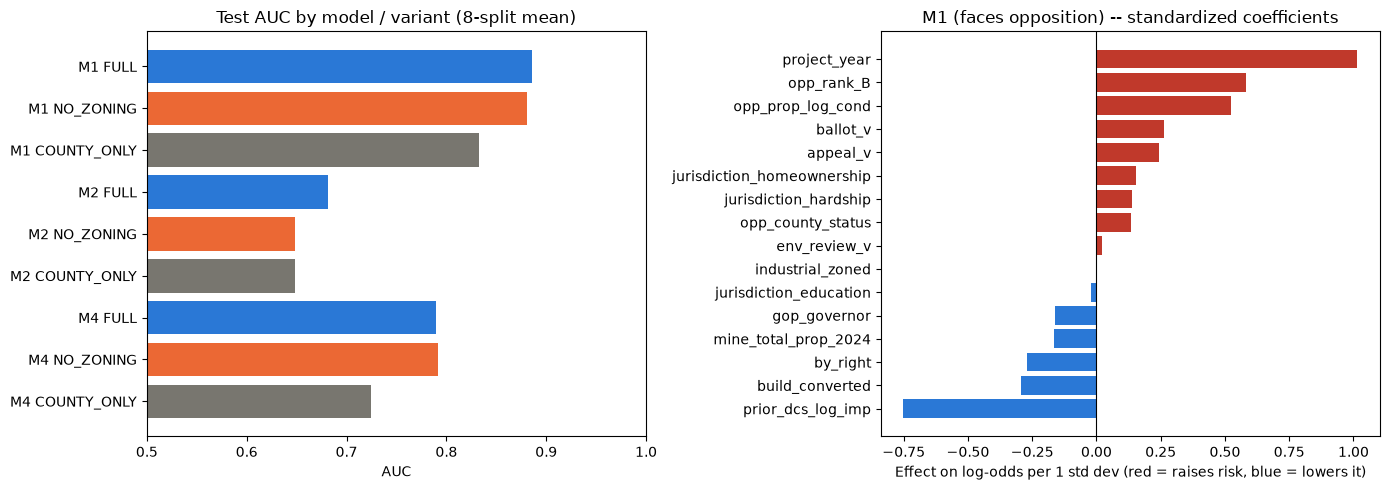

In [6]:

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10



import pickle
import numpy as np
import pandas as pd

scen = pickle.load(open("scenario_models.pkl", "rb"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: test AUC by model / variant ---
rows = []
for m in ["M1", "M2", "M4"]:
    for v in ["FULL", "NO_ZONING", "COUNTY_ONLY"]:
        if v in scen[m]:
            rows.append((f"{m} {v}", scen[m][v]["test_auc_mean8"]))
labels, aucs = zip(*rows)
colors = ["#2a78d6" if "FULL" in l else "#78766f" if "COUNTY_ONLY" in l else "#eb6834" for l in labels]
axes[0].barh(labels, aucs, color=colors)
axes[0].set_xlim(0.5, 1.0)
axes[0].set_title("Test AUC by model / variant (8-split mean)")
axes[0].set_xlabel("AUC")
axes[0].invert_yaxis()

# --- Right: standardized coefficients for M1 FULL -- which variables matter most ---
entry = scen["M1"]["FULL"]
pipe = entry["pipe"]
coefs = pipe.named_steps["lr"].coef_[0]
preds = entry["preds"]
order = np.argsort(coefs)
axes[1].barh([preds[i] for i in order], [coefs[i] for i in order],
             color=["#c0392b" if c > 0 else "#2a78d6" for c in coefs[order]])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("M1 (faces opposition) -- standardized coefficients")
axes[1].set_xlabel("Effect on log-odds per 1 std dev (red = raises risk, blue = lowers it)")

plt.tight_layout()
plt.show()